# Multiple Linear Regression 

In [1]:
from sklearn.datasets import fetch_california_housing


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
claifornia=fetch_california_housing()

In [4]:
claifornia.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [5]:
type(claifornia)

sklearn.utils._bunch.Bunch

In [6]:
print(claifornia.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [7]:
claifornia.target_names

['MedHouseVal']

In [8]:
print(claifornia.data)

[[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]


In [9]:
print(claifornia.target)

[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [10]:
claifornia.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [11]:
## lets prepare the dataframe 
dataset =pd.DataFrame(claifornia.data,columns=claifornia.feature_names)

In [12]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [13]:
dataset['Price']=claifornia.target

In [14]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [15]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [16]:
dataset.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [19]:
import seaborn as sns


<Axes: >

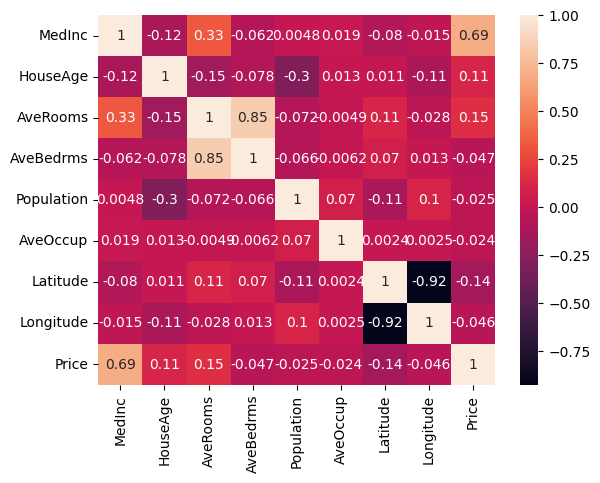

In [22]:
sns.heatmap(dataset.corr(),annot=True)

In [23]:
## independent and dependent featurex 
x=dataset.iloc[:,:-1]  # independent features
y=dataset.iloc[:,-1] # dependent features 

In [31]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.32,random_state=10)

In [32]:
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((14035, 8), (14035,), (6605, 8), (6605,))

In [33]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [34]:
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [36]:
x_train

array([[-0.43446767, -0.36251613, -0.36621006, ...,  0.10490486,
        -0.69757178,  0.79348401],
       [ 0.07463444, -1.94763478, -0.06391821, ..., -0.1502487 ,
        -1.15487985,  1.16718532],
       [ 1.12652026, -0.52102799,  0.47910237, ..., -0.00673937,
         0.94500416, -1.10491863],
       ...,
       [ 0.88936782, -1.78912292, -0.21330563, ...,  0.09659309,
         0.78634626, -1.10491863],
       [-0.87849099,  0.50929913, -1.10164446, ...,  0.18688831,
        -0.77223432,  0.66891691],
       [-0.62858842, -0.99656359, -0.60553953, ..., -0.08441144,
         0.77701344, -1.14976279]])

In [37]:
x_test

array([[ 0.7537383 , -1.31358732, -0.39424664, ...,  0.12739008,
        -0.68823896,  0.19556192],
       [ 0.05986554, -0.12474833, -0.33112678, ..., -0.12069766,
         0.89367367, -1.3640182 ],
       [ 0.34525597, -1.31358732, -0.41057276, ..., -0.15656691,
        -0.916893  ,  0.89812038],
       ...,
       [-0.65584182, -0.0454924 , -1.0531074 , ...,  0.04111748,
        -0.73023664,  0.65396886],
       [ 0.05471236, -0.20400426, -0.57844911, ..., -0.08054109,
         0.79567908, -1.20457231],
       [ 3.15124108,  1.22260253,  0.66436989, ..., -0.03609794,
        -0.70223819,  0.7336918 ]])

## Model Training 

In [38]:
from sklearn.linear_model import LinearRegression

In [39]:
regressor=LinearRegression()

In [40]:
regressor

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
regressor.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [43]:
# slope 
regressor.coef_

array([ 0.82774303,  0.12320729, -0.27185476,  0.33004122,  0.00131257,
       -0.02826922, -0.92802416, -0.89347156])

In [44]:
# Intercept 

regressor.intercept_

np.float64(2.063808933380839)

In [46]:
## prediction for the test data
y_pred=regressor.predict(x_test)

In [48]:
y_pred

array([3.00420827, 2.58049681, 2.34873495, ..., 1.75243062, 2.53218661,
       4.53176327])

In [54]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

print("MSE : ",mean_squared_error(y_test,y_pred))
print("MAE : ",mean_absolute_error(y_test,y_pred))
print("RMSE : ",np.sqrt(mean_squared_error(y_test,y_pred)))

MSE :  0.5536168662930454
MAE :  0.5373922852734554
RMSE :  0.7440543436423481


In [56]:
## r-squared and adjusted r-square 
from sklearn.metrics import r2_score


In [58]:
score=r2_score(y_test,y_pred)
print(score)

0.5950411546769923


In [59]:
## adjusted r square 

1-(1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)


0.5945499977997055

## Assumptions 


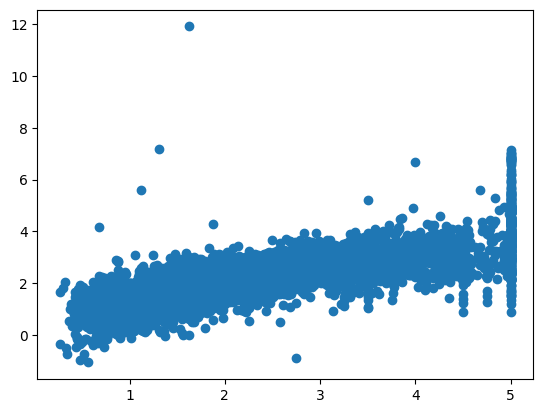

In [62]:
plt.scatter(y_test,y_pred)

In [63]:
residuals=y_test-y_pred

In [66]:
residuals

20303   -1.330208
16966    0.960503
10623   -0.746735
6146    -0.306622
2208    -0.663731
           ...   
14131   -0.165595
3320     0.306046
4390     0.122569
17926    0.096813
6732     0.468247
Name: Price, Length: 6605, dtype: float64

C:\Users\Madhav Yadav\AppData\Local\Temp\ipykernel_952\3762910054.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals,kde=True)


<Axes: xlabel='Price', ylabel='Density'>

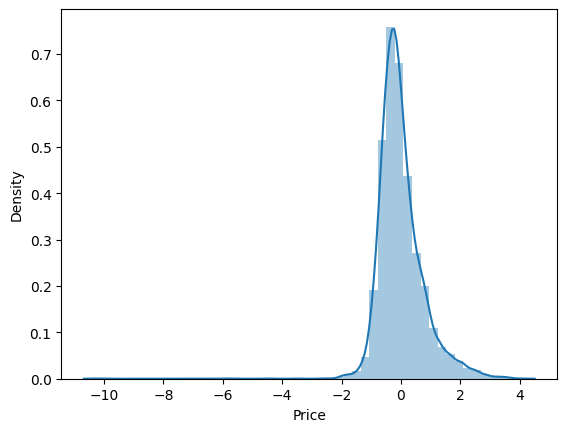

In [68]:
sns.distplot(residuals,kde=True)

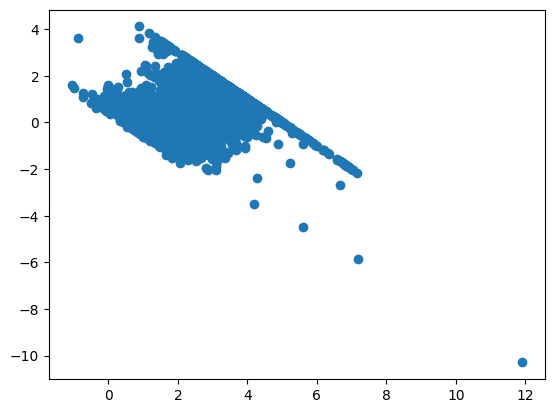

In [69]:
## scatter plot with residuals 

plt.scatter(y_pred,residuals)

## Pickling 

Python pickle module is used for serialising and de-serialising a python object structure . Any object in python can be picked so that it can seved on disk . What pickle does is that is "serialises" The object first before writing it to file. Picking is a way to convert a 
python object (list, dict etc) into a character stream. The idea is that this character stream contains all the information necessary to reconsturct the object in another python scripts

In [70]:
import pickle
pickle.dump(regressor,open('regressor.pkl','wb'))

In [72]:
model=pickle.load(open('regressor.pkl','rb'))


In [73]:
model.predict(x_test)

array([3.00420827, 2.58049681, 2.34873495, ..., 1.75243062, 2.53218661,
       4.53176327])